In [19]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget


In [20]:
checkpoint_epoch = 0
n_samples_test = 100
split = "test"
dataset = "biased_00"

conditions = ["base_model_0", "base_model_10", "base_model_20"]

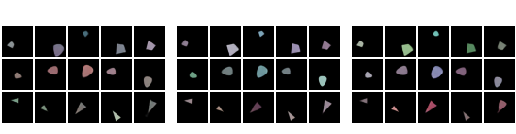

In [21]:
def plot_conditions_comparison(images_per_condition, titles, nrow=5):
    """
    images_per_condition: liste de tableaux d'images (une entrée par condition)
    titles: liste de titres (même longueur), ex: noms des conditions
    """
    n_cond = len(images_per_condition)
    grids = [get_grid_numpy(imgs, nrow=nrow) for imgs in images_per_condition]

    dpi = 100
    grid_h, grid_w = grids[0].shape[:2]
    fig_w = (grid_w * n_cond) / dpi
    fig_h = (grid_h + 30) / dpi

    fig, axes = plt.subplots(1, n_cond, figsize=(fig_w, fig_h), dpi=dpi)
    if n_cond == 1:
        axes = [axes]

    for ax, grid, title in zip(axes, grids, titles):
        ax.imshow(grid, interpolation='nearest')
        ax.axis('off')

    fig.subplots_adjust(top=0.88, bottom=0.0, right=1.0, left=0.0, wspace=0.05)
    return fig


vision4_per_condition = []

with total_silence():
    for condition in conditions:
        global_workspace, domain_mods, gw_mod, visual_module, original_data, latent_domains, modules_name = \
            get_modules_data_from_exp(
                experiment_name=condition,
                n_samples_test=n_samples_test,
                split=split,
                checkpoint_epoch=checkpoint_epoch
            )

        objects = get_objects_from_v_latents(
            latent_domains,
            gw_mod,
            global_workspace,
            modules_name,
            modality_from='attr',
            modality_through='color',
            modality_main=['attr'],
            modality_add='color',
            start_v=False
        )

        cat = []
        if 'attr' in modules_name:
            cat = original_data['attr'][0]
        if 'cat' in modules_name:
            cat = original_data['cat']

        decoded_images_v4 = visual_module.decode_images(objects['vision4'])
        images_5_per_cat = get_n_per_category(decoded_images_v4, cat, 5)
        vision4_per_condition.append(images_5_per_cat)

        del decoded_images_v4

fig = plot_conditions_comparison(vision4_per_condition, titles=conditions, nrow=5)
plt.show()

In [22]:
torch.cuda.empty_cache()